In [1]:
import os
import numpy as np
import rasterio
import xarray as xr

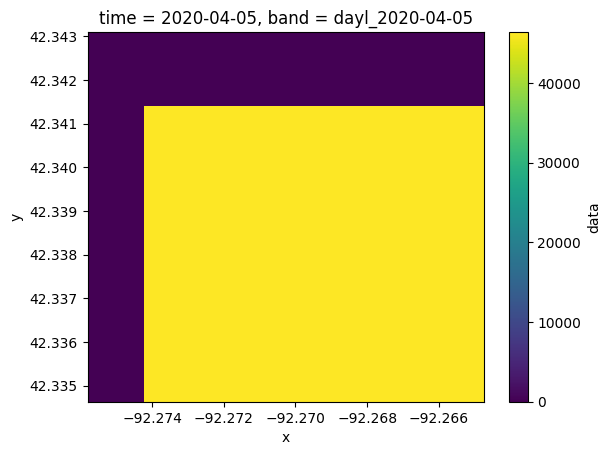

In [13]:
xdata = xr.open_dataset('unprocessed_data/WEATHER/ST2020IA0004_Soybean.nc')
xdata['data'].isel(band=0, time=0).plot()

In [11]:
with rasterio.open('unprocessed_data/yield_geotiffs/ST2019IA0007_Soybean.tif') as dataset:
    # Get the shape (height, width) and number of bands
    height, width = dataset.shape
    bands = dataset.count
    print(dataset.shape)

    

(121, 121)


In [ ]:
np.load('unprocessed_data/S1GRD/ST2024IA0008_Soybean.tif',allow_pickle=True)

ValueError: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.

In [20]:
test = np.load('unprocessed_data/WEATHER/ST2019IA0007_Soybean.npy')
test.shape

(5, 7, 4, 5)

In [ ]:
root_dir = 'processed_data_monthly'
shapes = set()
dtypes = dict()  # dtype: sample file

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            try:
                arr = np.load(file_path, mmap_mode='r')
                # Only keep the last two dimensions
                shape = arr.shape[-2:] if len(arr.shape) >= 2 else arr.shape
                shapes.add(shape)
                if arr.dtype not in dtypes:
                    dtypes[arr.dtype] = file_path
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

print("Unique (-1, -2) shapes in processed_data_monthly:")
for s in sorted(shapes):
    print(s)

print("\nUnique data types in processed_data_monthly (with a sample file):")
for dtype, sample_file in dtypes.items():
    print(f"{dtype}: {sample_file}")

Unique (-1, -2) shapes in processed_data_monthly:
(224, 224)

Unique data types in processed_data_monthly:
float32
float64


In [3]:
test = np.load('processed_data_monthly/S2L2A/ST2019IA0007_Soybean.npy')
test.shape

(6, 12, 224, 224)

In [ ]:
root_dir = './data_download/S1/final_s1'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
root_dir = './unprocessed_data/yield_geotiffs'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
batch['image']['S2L2A'].shape

In [ ]:
import geopandas as gpd

In [ ]:
gpd.read_parquet('Yield_2024.parquet')